Using the dataset provided by the instructor in class and variables of your choice demonstrate using the R environment the application of the following machine learning algorithms. For each algorithm explain what variables you used and what kind of question(s) the algorithm answers. Provide screenshots of the results.



41. Linear regression

42. Multiple linear regression

43. Logistic regression

44. Multiple logistic regression

45. kNN (k = 1)

46. kNN (k = 5)

47. kNN (k = 10)

48. kNN (k = 15)

49. Decision tree

50. Random forests



Load iris dataset 

In [86]:

from sklearn.datasets import load_iris
import pandas as pd

iris = pd.read_csv("iris.csv")

iris.head()



,sepal_length,sepal_width,petal_length,petal_width,species
0,7.4,3.3,5.6,2.2,Iris-virginica
1,4.7,2.7,1.6,0.3,Iris-setosa
2,5.2,3.6,1.3,0.2,Iris-setosa
3,6.1,2.6,5.7,2.4,Iris-virginica
4,5.0,3.2,1.3,0.3,Iris-setosa


convert the dataset into dataframe for easy processing

In [87]:
import pandas as pd
iris_df = iris

iris_df.describe()



,sepal_length,sepal_width,petal_length,petal_width
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.840720,3.046820,3.758100,1.199930
std,0.822114,0.437627,1.750272,0.750695
min,4.000000,2.000000,1.000000,0.100000
25%,5.200000,2.700000,1.600000,0.300000
50%,5.800000,3.000000,4.200000,1.300000
75%,6.400000,3.300000,5.200000,1.800000
max,8.000000,4.500000,7.000000,2.500000


perform an exploratory data analysis 

In [88]:
iris_df.describe()



,sepal_length,sepal_width,petal_length,petal_width
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.840720,3.046820,3.758100,1.199930
std,0.822114,0.437627,1.750272,0.750695
min,4.000000,2.000000,1.000000,0.100000
25%,5.200000,2.700000,1.600000,0.300000
50%,5.800000,3.000000,4.200000,1.300000
75%,6.400000,3.300000,5.200000,1.800000
max,8.000000,4.500000,7.000000,2.500000


array([[<Axes: title={'center': 'sepal_length'}>,
        <Axes: title={'center': 'sepal_width'}>],
       [<Axes: title={'center': 'petal_length'}>,
        <Axes: title={'center': 'petal_width'}>]], dtype=object)

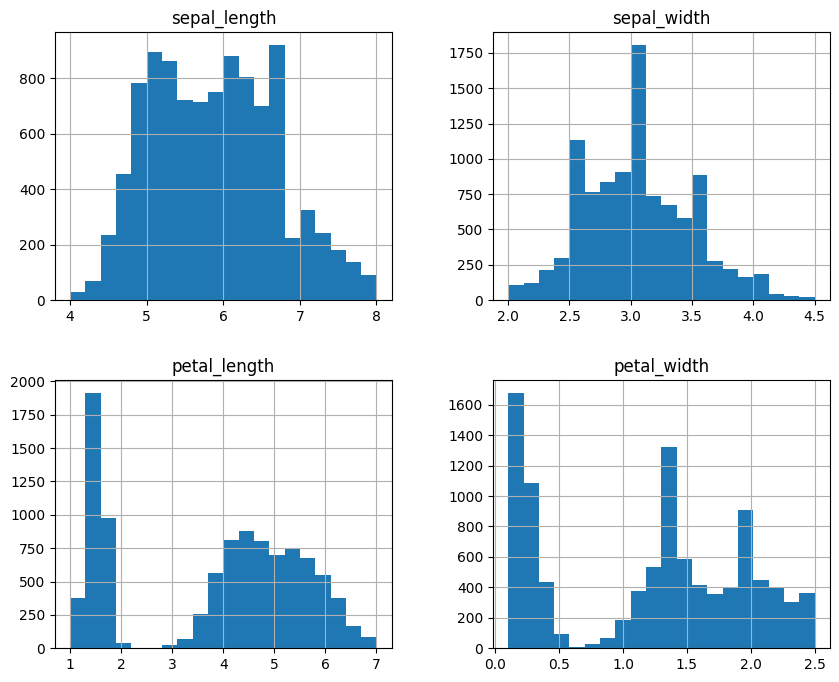

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns


iris_df.hist(figsize=(10, 8), bins=20)

categorical variables are ignored.
I do not see any outliers in the dataset

In [90]:
iris_df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

i do not see any missing values in the dataset.

array([[<Axes: xlabel='sepal_length', ylabel='sepal_length'>,
        <Axes: xlabel='sepal_width', ylabel='sepal_length'>,
        <Axes: xlabel='petal_length', ylabel='sepal_length'>,
        <Axes: xlabel='petal_width', ylabel='sepal_length'>],
       [<Axes: xlabel='sepal_length', ylabel='sepal_width'>,
        <Axes: xlabel='sepal_width', ylabel='sepal_width'>,
        <Axes: xlabel='petal_length', ylabel='sepal_width'>,
        <Axes: xlabel='petal_width', ylabel='sepal_width'>],
       [<Axes: xlabel='sepal_length', ylabel='petal_length'>,
        <Axes: xlabel='sepal_width', ylabel='petal_length'>,
        <Axes: xlabel='petal_length', ylabel='petal_length'>,
        <Axes: xlabel='petal_width', ylabel='petal_length'>],
       [<Axes: xlabel='sepal_length', ylabel='petal_width'>,
        <Axes: xlabel='sepal_width', ylabel='petal_width'>,
        <Axes: xlabel='petal_length', ylabel='petal_width'>,
        <Axes: xlabel='petal_width', ylabel='petal_width'>]], dtype=object)

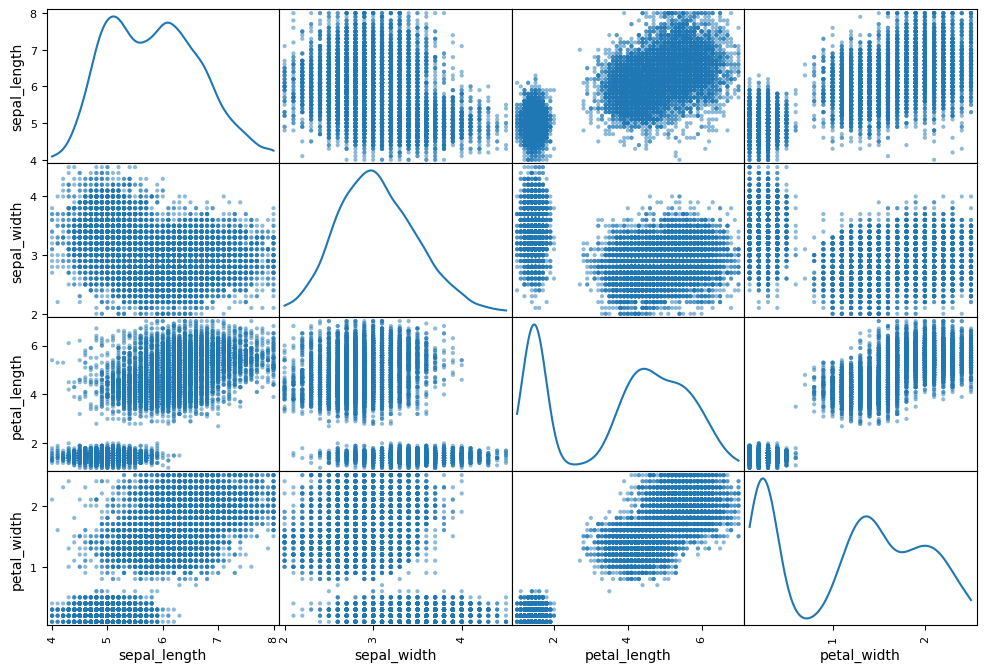

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

scatter_matrix(iris_df.drop(columns=["species"]), figsize=(12, 8), diagonal="kde")

In [60]:
from sklearn.model_selection import train_test_split

iris_df_target = iris_df["target"]

iris_df.drop(columns=["target"], inplace=True)

iris_train, iris_test, iris_train_target, iris_test_target = train_test_split(
    iris_df, iris_df_target, test_size=0.2, random_state=42)

iris_train.shape, iris_test.shape, iris_train_target.shape, iris_test_target.shape

((120, 4), (30, 4), (120,), (30,))

i chose random sampling to split the dataset into training and test sets. 
I set the random state to 42 to ensure that the results are reproducible. 
The test set will contain 20% of the data, while the training set will contain the remaining 80%.

array([[<Axes: xlabel='sepal length (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='sepal length (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='sepal width (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='petal length (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='petal width (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='petal width (cm)'>,
  

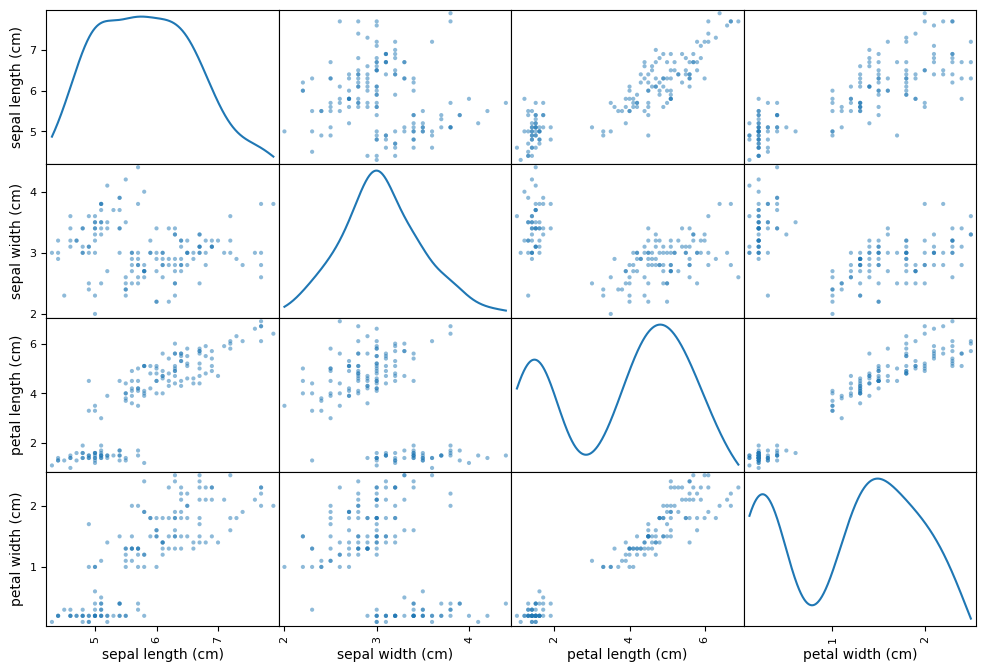

In [ ]:
from pandas.plotting import scatter_matrix

scatter_matrix(iris_df, figsize=(12, 8), diagonal="kde")


In [64]:
correlation_matrix = iris_df.corr()
correlation_matrix["petal width (cm)"].sort_values(ascending=False)



petal width (cm)     1.000000
petal length (cm)    0.962865
sepal length (cm)    0.817941
sepal width (cm)    -0.366126
Name: petal width (cm), dtype: float64

In [50]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()

model.fit(iris_train, iris_train_target)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
iris_train_predictions = model.predict(iris_train)

iris_test_predictions = model.predict(iris_test)

In [66]:
# Evaluate
from sklearn.metrics import mean_squared_error, r2_score
print(r2_score(iris_test_target, iris_test_predictions))        # closer to 1 = better
print(mean_squared_error(iris_test_target, iris_test_predictions))  # closer to 0 = better

0.9468960016420044
0.03711379440797691


The mean squared error of 0.03 shows high confidence in model generated.

Lets try logistic regression

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(iris_data, iris_target, test_size=0.2, random_state=42)



In [70]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(X_train, y_train)

y_train_predictions = model.predict(X_train)

y_test_predictions = model.predict(X_test)

In [71]:
confusion_matrix = pd.crosstab(y_test, y_test_predictions, rownames=["Actual"], colnames=["Predicted"])

confusion_matrix

Predicted,0,1,2
Actual,,,
0,10,0,0
1,0,9,0
2,0,0,11


In [73]:
precision = confusion_matrix[0][0] / (confusion_matrix[0][0] + confusion_matrix[1][0] + confusion_matrix[2][0])
recall = confusion_matrix[0][0] / (confusion_matrix[0][0] + confusion_matrix[0][1] + confusion_matrix[0][2])
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1_score:.2f}")

Precision: 1.00
Recall: 1.00
F1 Score: 1.00
